# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
# Import libraries and load data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection: 
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response:
1. The hotel manager, the people who set room prices, the marketing team, and the front desk staff.

2. The manager wants the rooms full and wants the hotel to make more money. The pricing people want to charge the right amount each night so they don't scare guests off or leave rooms too cheap. Marketing wants to know where guests come from so they spend money in the right places. The front desk wants to know how many guests are actually going to show up.

3. A lot of bookings get canceled, and every canceled room is money the hotel doesn't make. The question I'd want this data to answer is which kinds of bookings are most likely to cancel, so the hotel can plan for it before it happens.

## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:
# Check data quality
df.info()
print(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            94

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


### Reflection: 
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue? 

### ✍️ Your Response:
1. The company column is empty in 8,393 of the 9,404 rows, so it's almost useless. Agent is missing 2,335 and country is missing 266. There are also 1,674 duplicate rows. Agent and company are ID numbers, but they're saved as float64 like they're prices, and reservation_status_date is saved as text instead of a date. The lowest adr is -6.4, and a room price can't be negative.

2. I'd drop the company column since there's almost nothing in it. For agent, a blank probably just means no agent was used, so I'd fill those in as "none." The rows missing a country could say "Unknown." Then I'd remove the duplicates with drop_duplicates(), change agent to text and the date column to a real date, and take out the negative prices.

## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

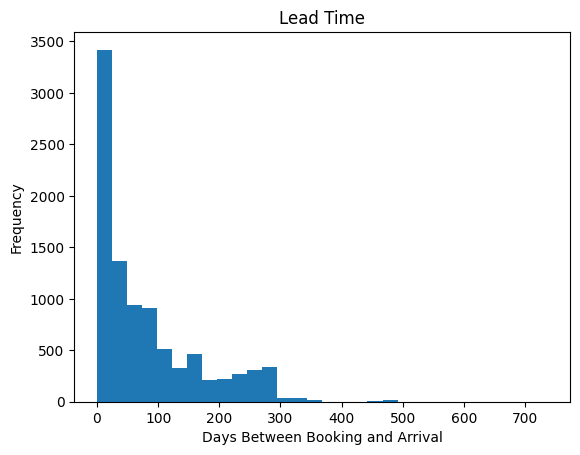

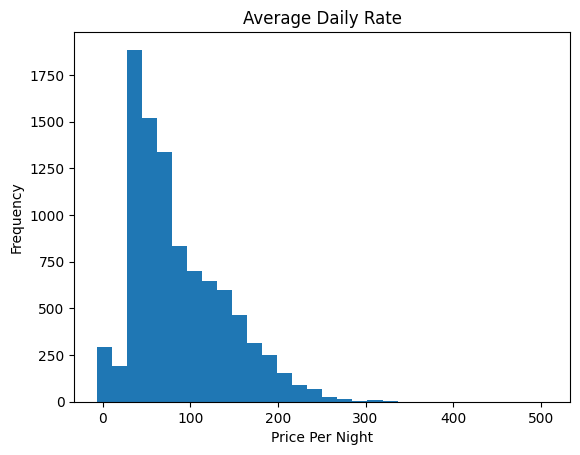

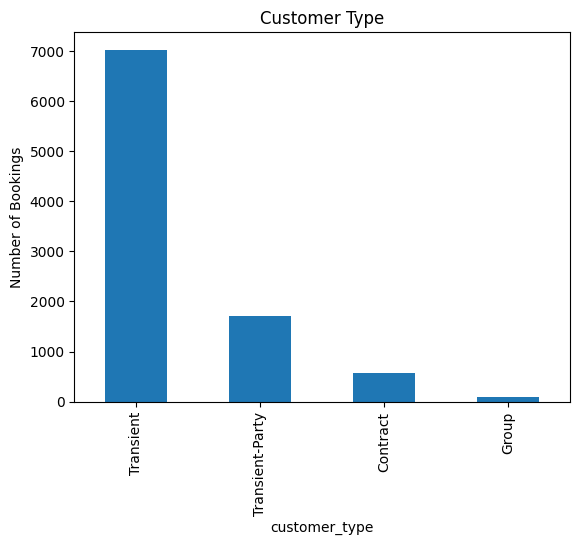

,lead_time,adr
count,9404.000000,9404.000000
mean,79.326244,86.843614
std,87.584146,53.759940
min,0.000000,-6.380000
25%,8.000000,45.000000
50%,48.000000,71.550000
75%,118.000000,120.600000
max,737.000000,508.000000


In [3]:
# Univariate analysis
df['lead_time'].plot(kind='hist', bins=30, title='Lead Time')
plt.xlabel('Days Between Booking and Arrival')
plt.show()

df['adr'].plot(kind='hist', bins=30, title='Average Daily Rate')
plt.xlabel('Price Per Night')
plt.show()

df['customer_type'].value_counts().plot(kind='bar', title='Customer Type')
plt.ylabel('Number of Bookings')
plt.show()

df[['lead_time', 'adr']].describe()

### Reflection: 
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response:
- **Variable 1 (lead_time):** Most people book pretty close to their stay. Half booked within 48 days, and a quarter booked 8 days or less. The histogram has a long tail to the right though, and some bookings were made up to 737 days ahead, which is about 2 years.
- **Variable 2 (adr):** The average price per night is about 87 and the middle is about 72, so a few expensive nights pull the average up. The highest is 508. Some rows are at 0 or even below 0, which doesn't make sense for a room.
- **Variable 3 (customer_type):** Transient guests are most of the bookings, about 7,000 out of 9,404. Transient-Party is next at about 1,700, and Contract and Group are pretty small. So this hotel mostly deals with regular travelers, not groups.

## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

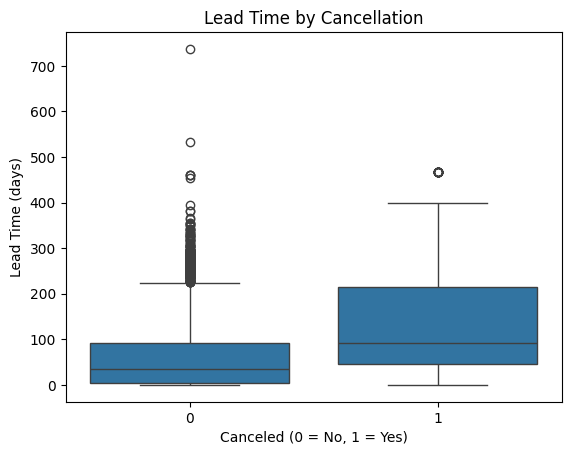

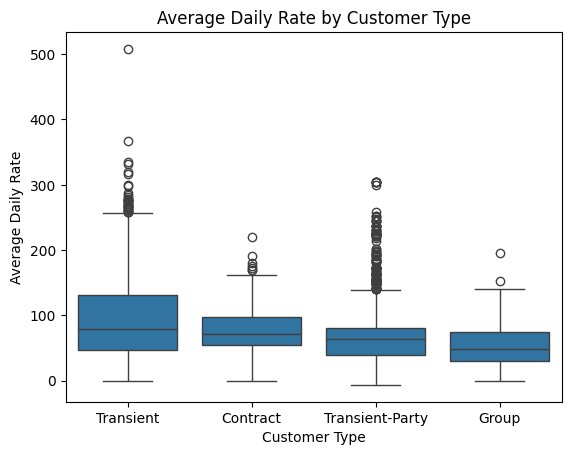

In [4]:
# Bivariate analysis
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time by Cancellation')
plt.xlabel('Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (days)')
plt.show()

sns.boxplot(x='customer_type', y='adr', data=df)
plt.title('Average Daily Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Average Daily Rate')
plt.show()

### Reflection: 
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response:
- **Relationship 1 (lead_time vs is_canceled):** Canceled bookings were made a lot earlier. The middle lead time for canceled bookings is around 90 days, compared to around 35 for bookings that weren't canceled. So the further ahead someone books, the more time their plans have to change. The hotel should keep a closer eye on bookings made months in advance.
- **Relationship 2 (adr vs customer_type):** Transient guests pay the most per night, with a middle price around 80. Group bookings pay the least, under 50, which makes sense since groups usually get a deal. Transient guests are most of the bookings and pay the most, so they're the ones the hotel can least afford to lose.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection: 
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response:
1. People who book far ahead cancel a lot more than people who book close to their stay.

2. Mostly variability. Lead times go anywhere from 0 to 737 days, and people cancel for all kinds of reasons the data doesn't even show, like their plans changing or finding a cheaper place. There's some variety too, since lead time is mixed in with other things like customer type and how the room was booked.

3. Predictive analytics, because the hotel needs to guess which bookings are going to cancel before it happens. If they knew that, they could send those guests a reminder or overbook a little on those nights.

## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection: 
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response:

1. About 1 in 4 bookings got canceled (the is_canceled mean is 0.248 in the describe table). Bookings made way ahead of time cancel more. Most guests are transient, and they also pay the most per night.

2. The manager and the pricing people want full rooms and more money, and cancellations hurt both. The front desk and marketing need to know who is actually going to show up.

3. I'd send reminder emails or texts to guests who booked more than a couple months out and ask them to confirm. For nights with a lot of far-out bookings, the hotel could overbook a little since some of those will probably cancel.

4. One of my learning outcomes is making a before and after case study for my dental clients that tracks patient show rates. Hotel cancellations are basically the same thing as patients not showing up. This made me want to check whether patients who book further out no-show more, since that could be one of the numbers in my case study. My other outcome is about finding a client's real problem, and this is a good example of it. A hotel would probably say it needs more bookings, when a big part of the problem is losing the bookings it already has.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"